In [15]:
# Note: requires access to the BigQuery project banded-elevator-260003.
# Outputs are pre-rendered above — view the notebook directly on GitHub.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import auth
auth.authenticate_user()  # prompts a one-time Google login

import pandas_gbq

In [17]:
# ── LOAD ──────────────────────────────────────────────────────────────────────

In [18]:
from google.colab import auth
auth.authenticate_user()  # prompts a one-time Google login

import pandas_gbq

PROJECT_ID = "banded-elevator-260003"

orders = pandas_gbq.read_gbq(
    "SELECT * FROM `banded-elevator-260003.dbt_shafiq.fct_orders`",
    project_id=PROJECT_ID
)

customers = pandas_gbq.read_gbq(
    "SELECT * FROM `banded-elevator-260003.dbt_shafiq.dim_customers`",
    project_id=PROJECT_ID
)

products = pandas_gbq.read_gbq(
    "SELECT * FROM `banded-elevator-260003.dbt_shafiq.dim_products`",
    project_id=PROJECT_ID
)

Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|


In [19]:
# ── SECTION 1: Shape & types ───────────────────────────────────────────────────
print("Orders shape:", orders.shape)
print(orders.dtypes)
print(orders.head())

Orders shape: (124866, 8)
order_id                       Int64
customer_id                    Int64
order_status                  object
ordered_at       datetime64[us, UTC]
delivered_at     datetime64[us, UTC]
line_count                     Int64
revenue                      float64
delivery_days                  Int64
dtype: object
   order_id  customer_id order_status                ordered_at delivered_at  \
0       868          682    Cancelled 2026-07-05 07:17:57+00:00          NaT   
1      1713         1355    Cancelled 2025-06-09 08:49:47+00:00          NaT   
2      2735         2181    Cancelled 2025-02-01 09:49:12+00:00          NaT   
3      3310         2664    Cancelled 2023-03-17 09:07:19+00:00          NaT   
4      3862         3095    Cancelled 2025-01-18 19:48:16+00:00          NaT   

   line_count    revenue  delivery_days  
0           1  13.810000           <NA>  
1           1  61.750000           <NA>  
2           1   9.990000           <NA>  
3           1  

In [20]:
# ── SECTION 2: Null audit ─────────────────────────────────────────────────────
print("\nNull counts — orders:")
print(orders.isna().sum())

# Insight to add as a comment:
# e.g. "delivered_at is null for X% of orders — expected for Cancelled/Processing status"



Null counts — orders:
order_id             0
customer_id          0
order_status         0
ordered_at           0
delivered_at     80942
line_count           0
revenue              0
delivery_days    80942
dtype: int64


order_status
Shipped       37271
Complete      31339
Processing    25127
Cancelled     18544
Returned      12585
Name: count, dtype: int64


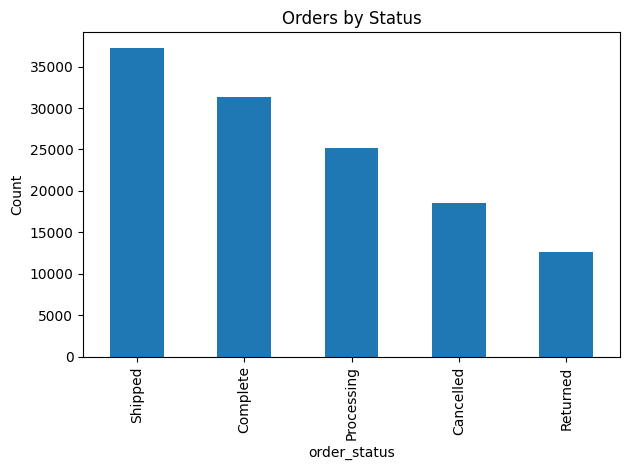

In [21]:
# ── SECTION 3: Order status distribution ──────────────────────────────────────
status_counts = orders['order_status'].value_counts()
print(status_counts)

status_counts.plot(kind='bar', title='Orders by Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_566/592616229.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  orders['month'] = orders['ordered_at'].dt.to_period('M')


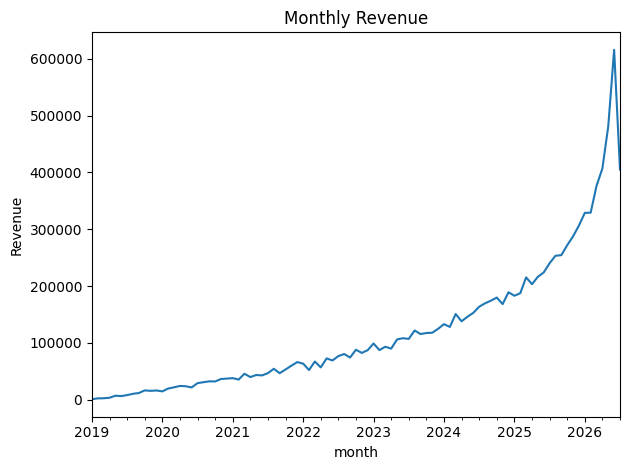

In [22]:
# ── SECTION 4: Revenue by month ───────────────────────────────────────────────
orders['ordered_at'] = pd.to_datetime(orders['ordered_at'])
orders['month'] = orders['ordered_at'].dt.to_period('M')

monthly_revenue = orders.groupby('month')['revenue'].sum()
monthly_revenue.plot(kind='line', title='Monthly Revenue')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

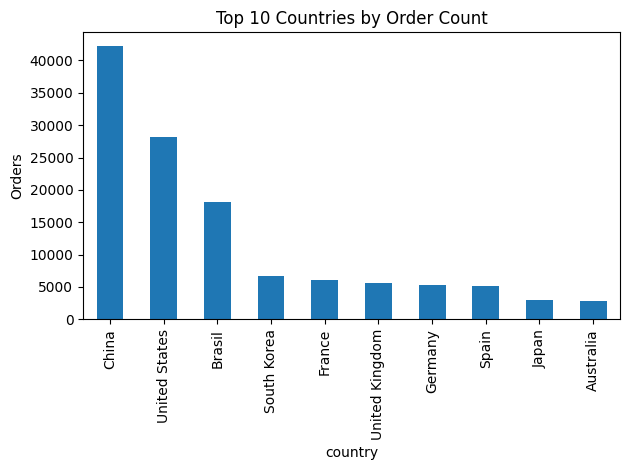

In [23]:
# ── SECTION 5: Top 10 countries by order count ────────────────────────────────
# Join orders to customers to get country
orders_with_country = orders.merge(
    customers[['customer_id', 'country']],
    on='customer_id',
    how='left'
)
top_countries = orders_with_country['country'].value_counts().head(10)
top_countries.plot(kind='bar', title='Top 10 Countries by Order Count')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()